In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report

## 📂 Data Loading & Type Conversion

### 🔢 Converting 'TotalCharges' to Numeric
---

### 🔍 Handling Missing Values
---

In [119]:
df=pd.read_csv("../Data/Telco-Customer-Churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

## 🎯 Feature Selection & Encoding

### 🔢 Binary Encoding ('Yes'/'No' ➔ 1/0)
---

### 📋 Selecting Features & Target Variable
---

In [120]:
df.drop(columns=["customerID"],inplace=True)
X=df.drop(columns=["Churn"])
y=df["Churn"].map({"Yes": 1 , "No": 0})


## 🗂️ Feature Segmentation

### 📈 Identifying Numeric Columns
---

### 🏷️ Identifying Categorical Columns
---

In [121]:
numeric_cols=X.select_dtypes(include=[np.number]).columns.tolist()
cate_cols=X.select_dtypes(include=['object']).columns.tolist()

## 🛠️ Data Preprocessing & Transformation

### 🏷️ One-Hot Encoding to Categorical Columns
---

### 📈 Applying Standard Scaler to Numeric Columns
---

In [122]:
X = pd.get_dummies(data=X,
                   columns=cate_cols,
                   drop_first=True,
                   dtype=np.int64)

scaler = StandardScaler()
scaler.fit(X[numeric_cols])
X[numeric_cols] = scaler.transform(X[numeric_cols])

## ✂️ Train-Test Split

### 📊 Splitting Data into Train & Test Sets (80/20)
---

In [123]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 🤖 Model Training (Baseline)

### ⚙️ Initializing and Fitting Logistic Regression with Class Balancing
---

In [124]:
model = LogisticRegression(solver='liblinear',
                           max_iter=1000,
                           class_weight='balanced')
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

## 🎯 Logistic Regression Model Evaluation

### 📊 Performance Metrics & Classification Report
---

In [125]:
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))
print(f1_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

0.6103092783505155
0.7313432835820896


/Users/serhat/Desktop/Customer churn project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/serhat/Desktop/Customer churn project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/serhat/Desktop/Customer churn project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 🌳 Alternative Modeling: Decision Tree

### ⚙️ Training a Depth-Limited Decision Tree Classifier
---

In [126]:
model_2 = DecisionTreeClassifier(max_depth=5,
                                 random_state=42,
                                 class_weight='balanced')
model_2.fit(X_train,y_train)
y_pred_2=model_2.predict(X_test)

## 🎯 Decision Tree Evaluation

### 📊 Performance Metrics & Classification Report
---

In [127]:
print(classification_report(y_test,y_pred_2))
print(f1_score(y_test,y_pred_2))
print(accuracy_score(y_test,y_pred_2))

              precision    recall  f1-score   support

           0       0.92      0.63      0.75      1033
           1       0.45      0.84      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.79      0.69      0.71      1407

0.5898876404494382
0.6886993603411514


## 🚀 Advanced Modeling: XGBoost Classifier

### ⚙️ Training an Optimized Gradient Boosting Model with Class Weighting
---

In [128]:
print(y_train.value_counts())
model_3=XGBClassifier(max_depth=5,
                      random_state=42,
                      learning_rate=0.1,
                      n_estimators=100,
                      reg_lambda=0.1,
                      scale_pos_weight=4130 / 1495,
)
model_3.fit(X_train,y_train)
y_pred_3=model_3.predict(X_test)

Churn
0    4130
1    1495
Name: count, dtype: int64


## 🎯 XGBoost Model Evaluation

### 📊 Performance Metrics & Classification Report
---

In [129]:
print(classification_report(y_test,y_pred_3))
print(f1_score(y_test,y_pred_3))
print(accuracy_score(y_test,y_pred_3))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1033
           1       0.50      0.76      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.74      0.75      1407

0.6048988285410011
0.736318407960199


## 🏆 Model Insights & Feature Importance

### 📌 Identifying the Key Drivers of Customer Churn via XGBoost
---

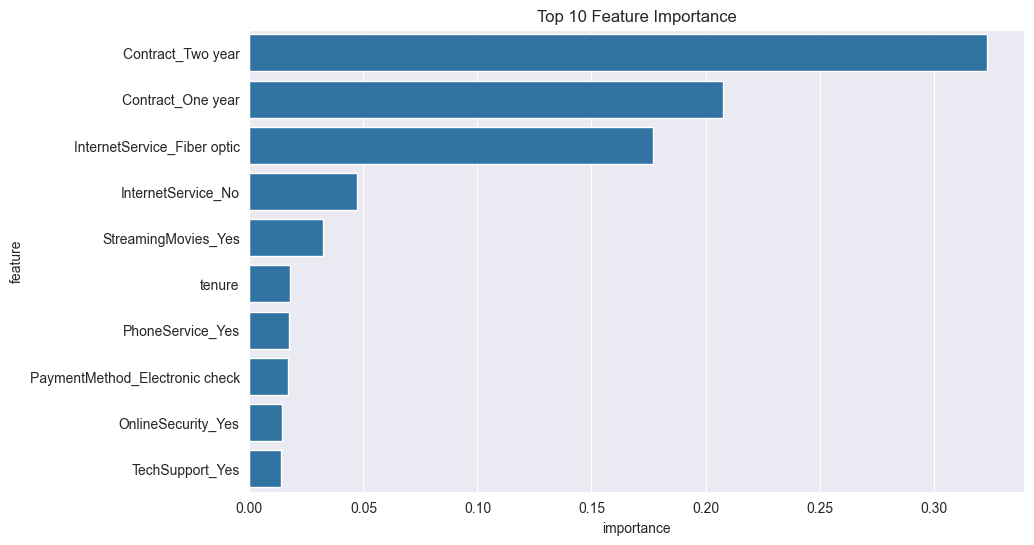

In [130]:
feature_importance=pd.DataFrame({
    'feature': X.columns,
    'importance': model_3.feature_importances_
})
feature_importance.sort_values('importance', ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importance')
plt.show()

## 🛡️ Model Validation & Robustness Check

### 🔄 10-Fold Stratified Cross-Validation on XGBoost
---

In [131]:
cv=StratifiedKFold(n_splits=10,shuffle=True, random_state=42)

cv_scores=cross_val_score(estimator=model_3,
                          X=X_train,
                          y=y_train,
                          cv=cv,
                          scoring='f1')

print(cv_scores)
print(cv_scores.mean())

[0.62824207 0.6395664  0.67966574 0.61797753 0.64150943 0.63157895
 0.61707989 0.63414634 0.61849711 0.6084507 ]
0.6316714163496562


## 🎛️ Hyperparameter Tuning & Optimization

### 🔍 Grid Search Cross-Validation for the Optimal XGBoost Configuration
---

In [132]:
param_grid= {
     'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'scale_pos_weight': [1, 2.76]
}

grid_search=GridSearchCV(
    estimator=model_3,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train,y_train)
print("---GridSearch Results---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")


Fitting 10 folds for each of 36 candidates, totalling 360 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_es

## 👑 Final Model Evaluation

### 📊 Performance Metrics & Classification Report for the Optimized XGBoost Model
---

In [133]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

0.7327647476901208
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



## 🏁 Final Model Comparison & Benchmark

### 📊 Evaluating Performance Metrics Across All Trained Models
---

In [134]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'XGBoost','XGBoost_tuned'],
    'Accuracy': [0.73, 0.69, 0.74,0.73],
    'Churn F1': [0.61, 0.59, 0.60,0.61]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Churn F1
0  Logistic Regression      0.73      0.61
1        Decision Tree      0.69      0.59
2              XGBoost      0.74      0.60
3        XGBoost_tuned      0.73      0.61
